In [ ]:
#  ChurnScope
### Exploring Customer Behavior, Retention Patterns & Revenue Risk

**Advanced Data Visualization & Storytelling with Python**

---

### Project Objective

ChurnScope is a data-driven customer churn analysis project designed to uncover
hidden patterns in customer behavior, identify high-risk customer segments,
and understand the business impact of customer churn through advanced
visualization and storytelling.

### Key Areas

- Customer Churn Analysis
- Customer Segmentation
- Behavioral Analysis
- Revenue-at-Risk Analysis
- Churn Risk Mapping
- Statistical Validation
- Advanced Data Visualization

**Developed using Python, Pandas, Matplotlib, Seaborn and Plotly.**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical analysis
from scipy.stats import chi2_contingency, mannwhitneyu

# Display settings
from IPython.display import display, Markdown

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

sns.set_theme(style="whitegrid")

print("Libraries successfully imported.")

Libraries successfully imported.


In [2]:
import pandas as pd
import os

file_path = os.path.expanduser("~/Documents/Telco-Customer-Churn.txt")

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 7043
Columns: 21


In [13]:
# Display the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
# Statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print("-", column)

Number of rows: 7043
Number of columns: 21

Column names:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges
- Churn


In [19]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

display(quality_report)

,Data Type,Missing Values,Missing %,Unique Values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


In [21]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count == 0:
    print("✓ No duplicate rows found.")
else:
    print("⚠ Duplicate rows detected.")

Duplicate rows: 0
✓ No duplicate rows found.


In [22]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values after conversion
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# Fill missing TotalCharges using median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Data cleaning completed.")

Missing TotalCharges: 11
Data cleaning completed.


In [3]:
print("Missing values after cleaning:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values after cleaning:


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

In [4]:
df["Churn_Binary"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df["Churn_Label"] = df["Churn"].map({
    "Yes": "Churned",
    "No": "Retained"
})

display(df[["Churn", "Churn_Binary", "Churn_Label"]].head())

,Churn,Churn_Binary,Churn_Label
0,No,0,Retained
1,No,0,Retained
2,Yes,1,Churned
3,No,0,Retained
4,Yes,1,Churned


In [5]:
df["Churn_Binary"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df["Churn_Label"] = df["Churn"].map({
    "Yes": "Churned",
    "No": "Retained"
})

display(df[["Churn", "Churn_Binary", "Churn_Label"]].head())

,Churn,Churn_Binary,Churn_Label
0,No,0,Retained
1,No,0,Retained
2,Yes,1,Churned
3,No,0,Retained
4,Yes,1,Churned


In [6]:
df["Charge_Group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

display(df["Charge_Group"].value_counts().sort_index())

Charge_Group
Low          1838
Medium       1622
High         2681
Very High     902
Name: count, dtype: int64

In [7]:
total_customers = len(df)
churned_customers = df["Churn_Binary"].sum()
retained_customers = total_customers - churned_customers

churn_rate = df["Churn_Binary"].mean() * 100
retention_rate = 100 - churn_rate

avg_monthly_charge = df["MonthlyCharges"].mean()
avg_tenure = df["tenure"].mean()

revenue_at_risk = df.loc[
    df["Churn_Binary"] == 1,
    "MonthlyCharges"
].sum()

print("=" * 60)
print("                 CHURNSCOPE — EXECUTIVE KPIs")
print("=" * 60)

print(f"Total Customers       : {total_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Retained Customers    : {retained_customers:,}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Retention Rate        : {retention_rate:.2f}%")
print(f"Average Monthly Charge: ${avg_monthly_charge:.2f}")
print(f"Average Tenure        : {avg_tenure:.2f} months")
print(f"Monthly Revenue Risk  : ${revenue_at_risk:,.2f}")

print("=" * 60)

                 CHURNSCOPE — EXECUTIVE KPIs
Total Customers       : 7,043
Churned Customers     : 1,869
Retained Customers    : 5,174
Churn Rate            : 26.54%
Retention Rate        : 73.46%
Average Monthly Charge: $64.76
Average Tenure        : 32.37 months
Monthly Revenue Risk  : $139,130.85


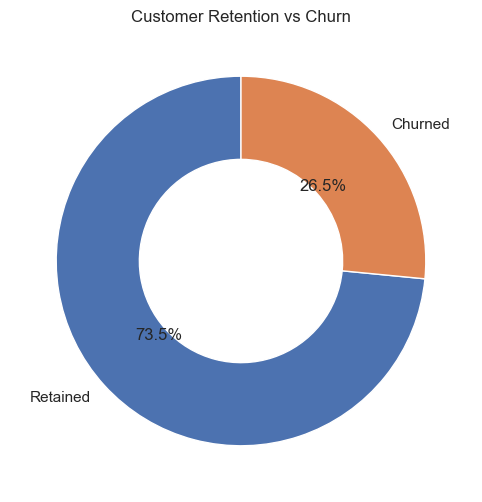

In [8]:
churn_counts = df["Churn_Label"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Customer Retention vs Churn")
plt.show()

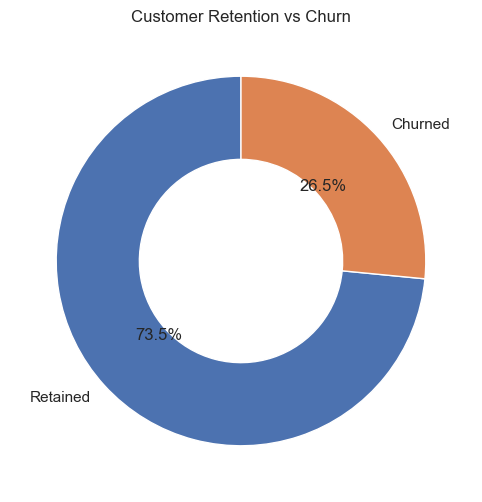

In [9]:
churn_counts = df["Churn_Label"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Customer Retention vs Churn")
plt.show()

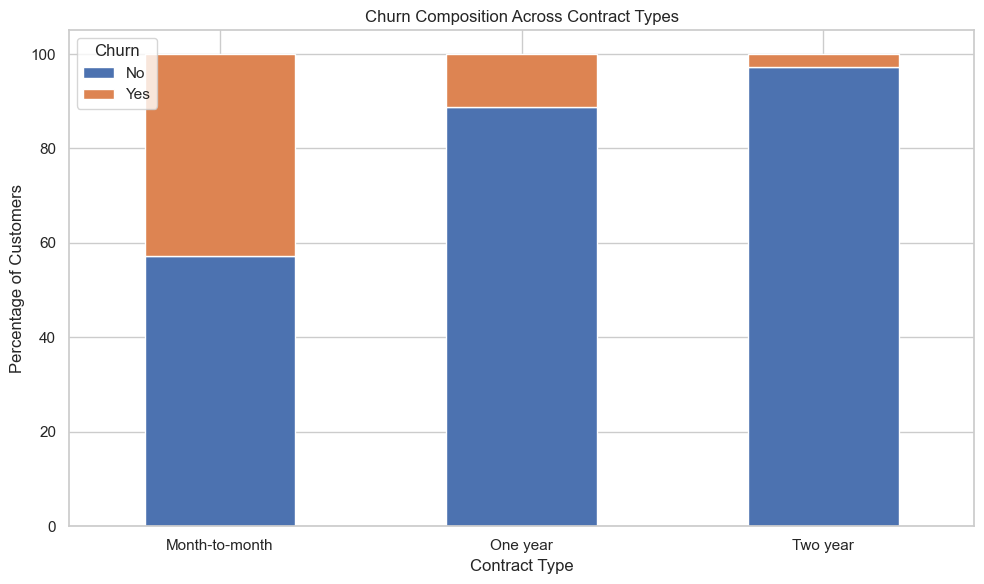

In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Churn Composition Across Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##  What does this tell us?

Contract structure provides an important behavioral dimension.

Instead of comparing only the number of churned customers, the visualization
compares churn proportions within each contract category.

This helps identify whether customer commitment level is associated with
different retention patterns.

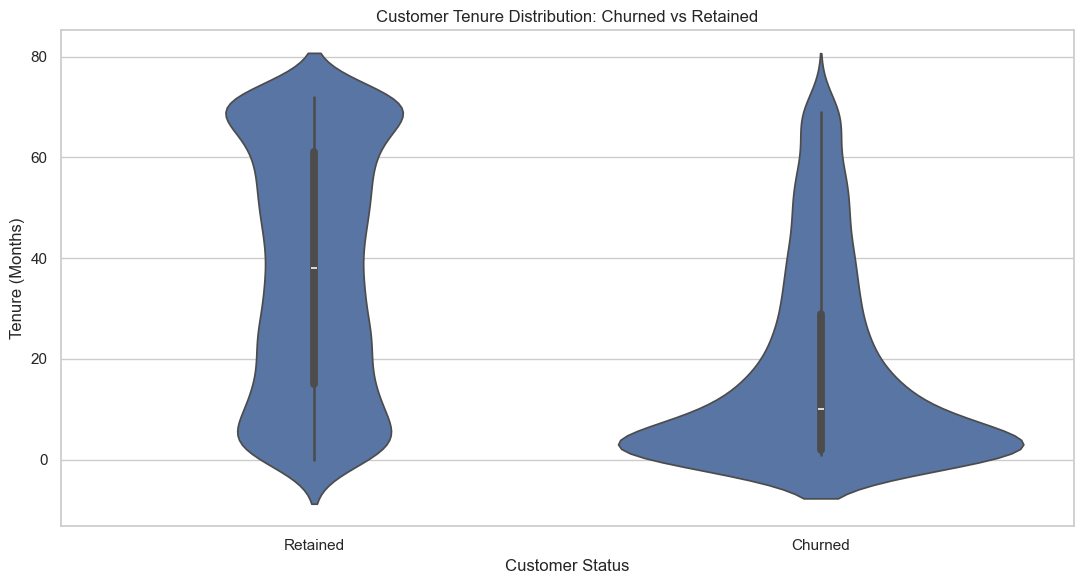

In [11]:
plt.figure(figsize=(11, 6))

sns.violinplot(
    data=df,
    x="Churn_Label",
    y="tenure",
    inner="box"
)

plt.title("Customer Tenure Distribution: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

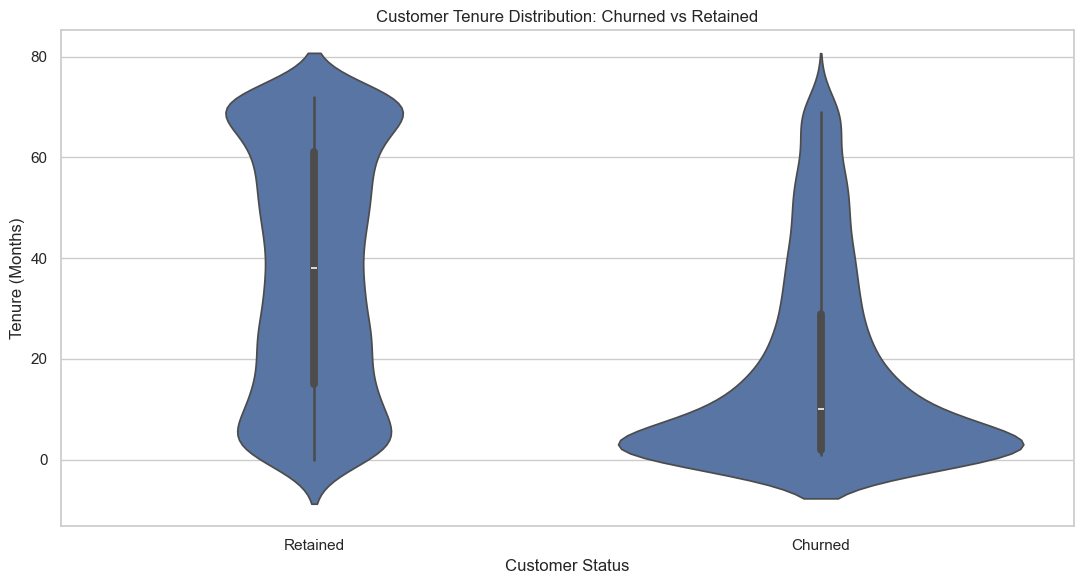

In [12]:
plt.figure(figsize=(11, 6))

sns.violinplot(
    data=df,
    x="Churn_Label",
    y="tenure",
    inner="box"
)

plt.title("Customer Tenure Distribution: Churned vs Retained")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [ ]:
##  What does this tell us?

Tenure provides a view of customer longevity.

The distribution allows us to compare not only average tenure but also
the spread and concentration of customer relationships.

### Business Question

> Are customers who leave concentrated among shorter-tenure relationships?

This helps identify whether the early customer lifecycle deserves additional
attention.

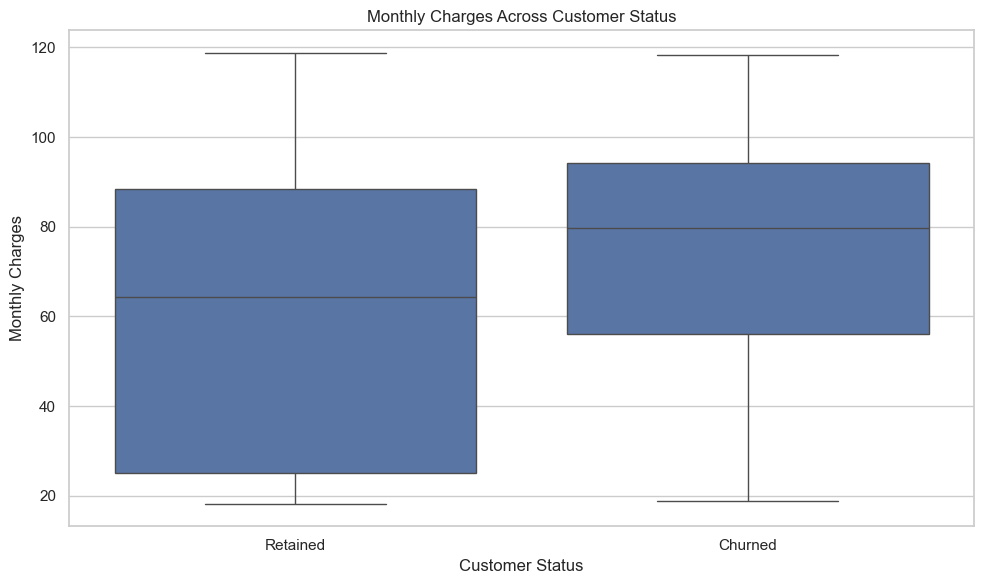

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn_Label",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Across Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

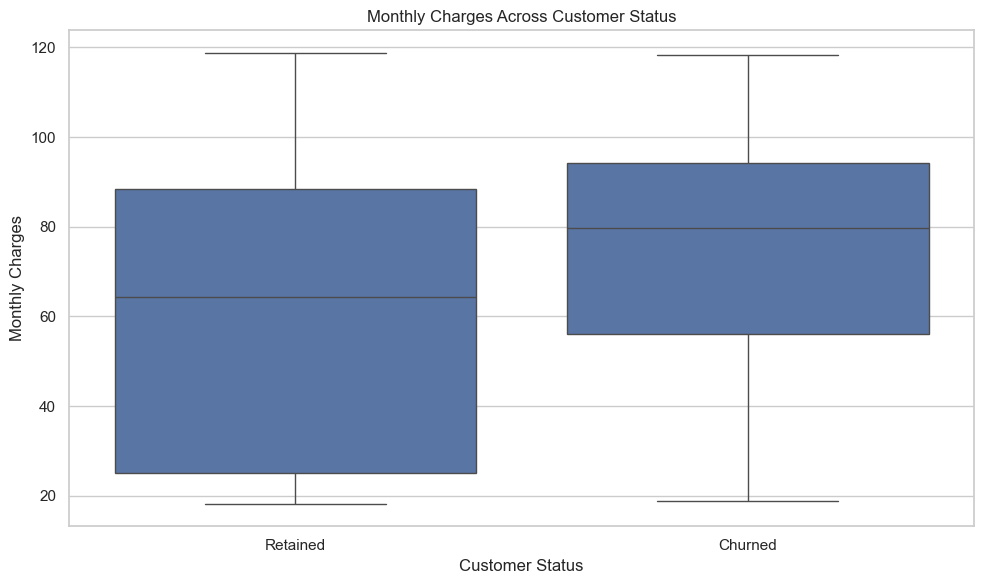

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn_Label",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Across Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [ ]:
##  Interpretation

The previous visualizations examine whether the distribution of monthly
charges differs between customers who remain and customers who churn.

This does not establish causation. Instead, it highlights a relationship
that can be investigated alongside contract type, services and tenure.

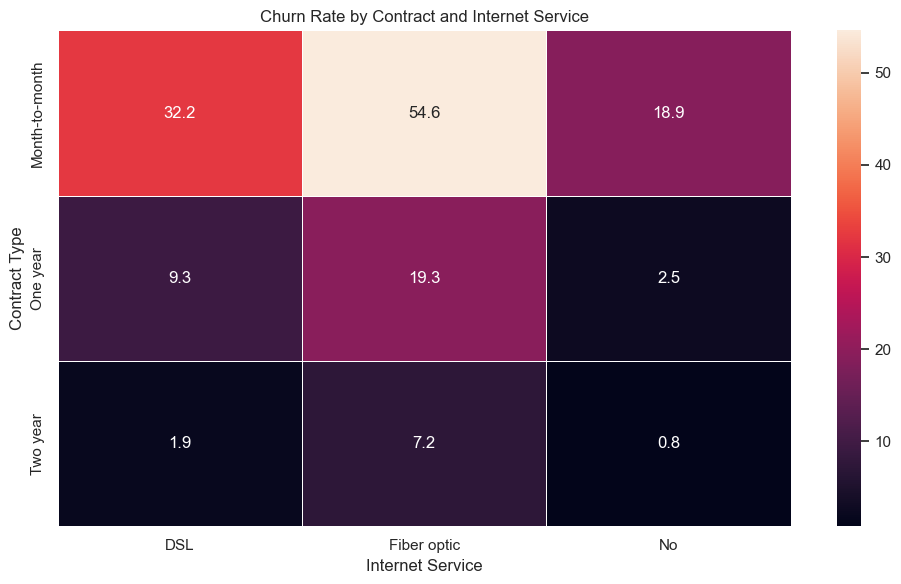

In [15]:
heatmap_data = pd.pivot_table(
    df,
    values="Churn_Binary",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")

plt.tight_layout()
plt.show()

In [ ]:
##  What does this tell us?

A single variable may not fully explain customer behavior.

This heatmap examines two dimensions simultaneously:

- Contract type
- Internet service

The resulting matrix helps identify combinations where churn rates differ
substantially.

This is more informative than examining each variable independently.

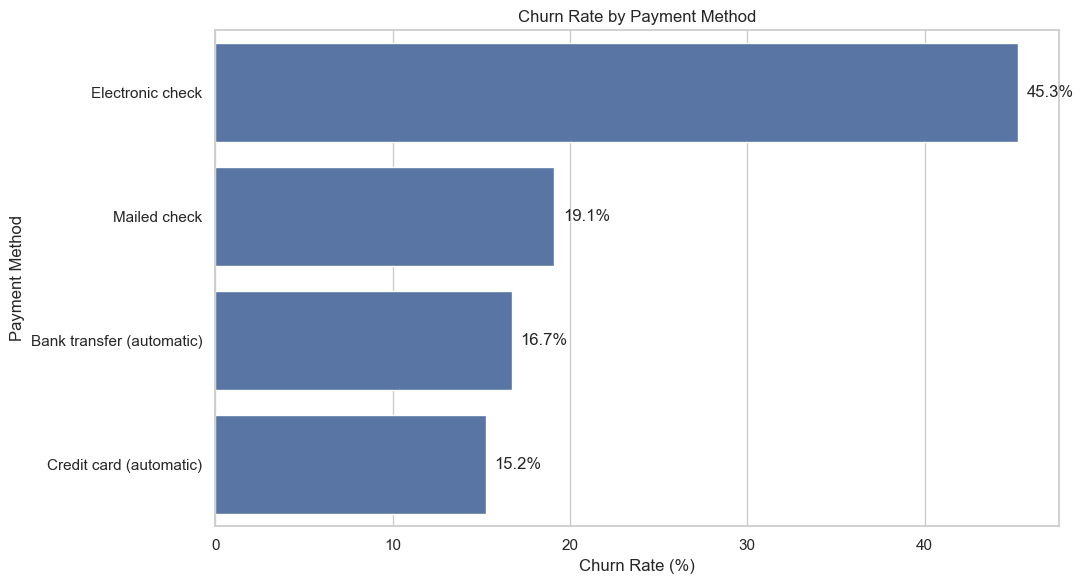

In [16]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Binary"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=payment_churn.values,
    y=payment_churn.index
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

for i, value in enumerate(payment_churn.values):
    plt.text(value + 0.5, i, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [ ]:
##  Business Perspective

Payment behavior can reveal differences in customer engagement and
subscription patterns.

The purpose of this visualization is not to claim that a payment method
causes churn, but to identify groups that show different churn patterns
and may deserve further investigation.

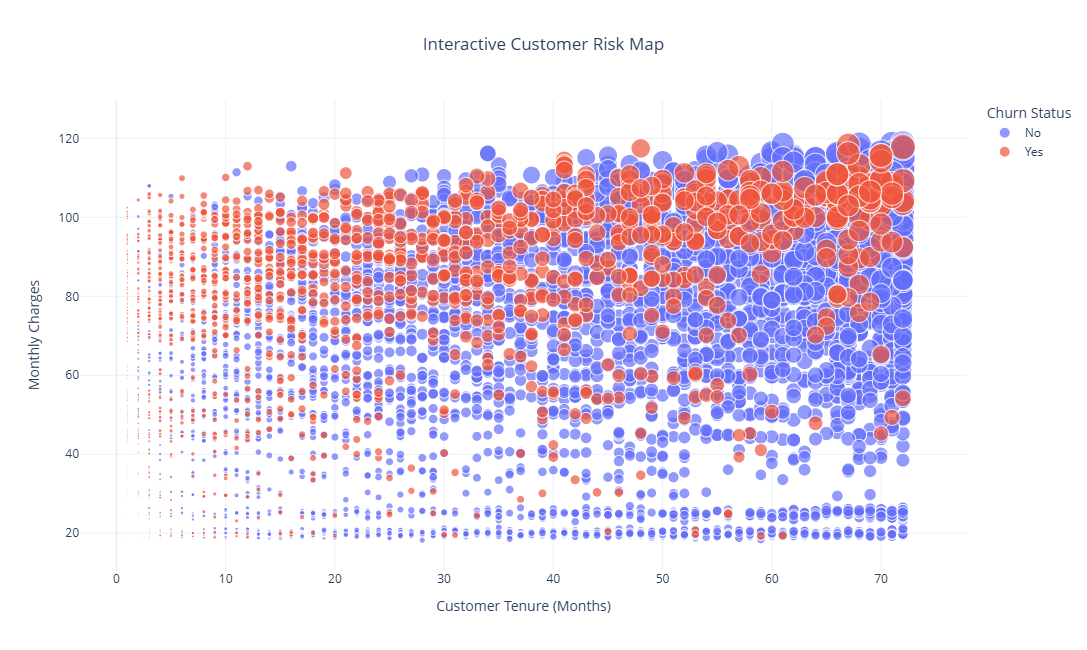

In [19]:
# ============================================================
# 23. INTERACTIVE CUSTOMER RISK MAP
# ============================================================

# Ensure numeric columns are properly converted
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows where required visualization values are missing
risk_df = df.dropna(
    subset=["tenure", "MonthlyCharges", "TotalCharges"]
).copy()

# Create interactive customer risk map
fig = px.scatter(
    risk_df,
    x="tenure",
    y="MonthlyCharges",
    color="Churn",
    size="TotalCharges",
    hover_name="customerID",
    hover_data=[
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TotalCharges"
    ],
    title="Interactive Customer Risk Map",
    labels={
        "tenure": "Customer Tenure (Months)",
        "MonthlyCharges": "Monthly Charges",
        "Churn": "Churn Status"
    },
    size_max=25
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=650
)

fig.show()

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

,Tenure Group,Churn Rate
0,0–6 Months,52.937205
1,7–12 Months,35.886525
2,13–24 Months,28.710938
3,25–36 Months,21.634615
4,37+ Months,11.929357


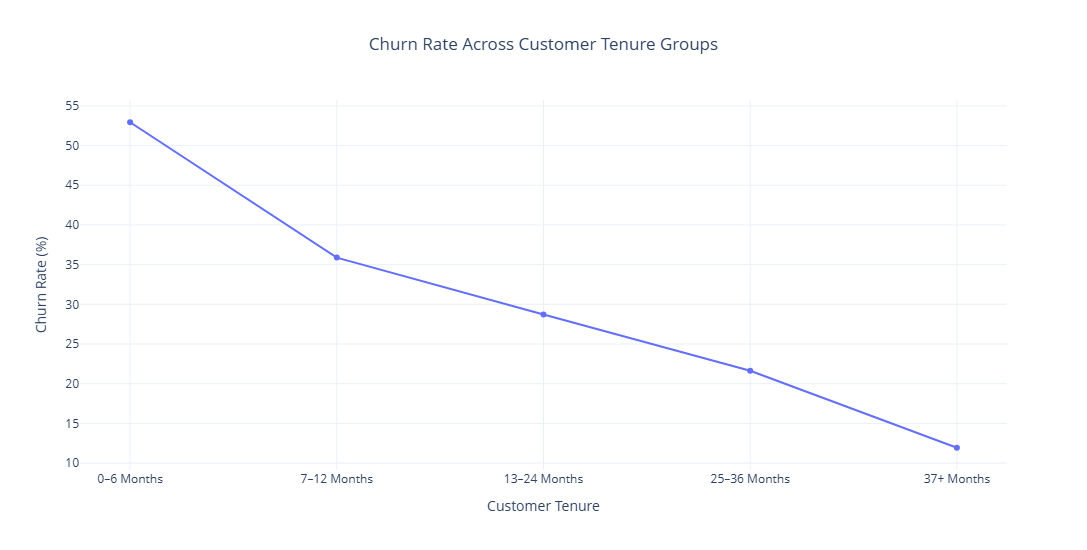

In [23]:
# ============================================================
# 24. TENURE COHORT CHURN ANALYSIS
# ============================================================

# Make sure tenure is numeric
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

# Create tenure groups
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 36, float("inf")],
    labels=[
        "0–6 Months",
        "7–12 Months",
        "13–24 Months",
        "25–36 Months",
        "37+ Months"
    ]
)

# Calculate churn rate for each tenure group
tenure_churn = (
    df.groupby("Tenure_Group", observed=False)["Churn_Binary"]
    .mean()
    .mul(100)
    .reset_index()
)

tenure_churn.columns = ["Tenure Group", "Churn Rate"]

# Display results
display(tenure_churn)

# Visualization
fig = px.line(
    tenure_churn,
    x="Tenure Group",
    y="Churn Rate",
    markers=True,
    title="Churn Rate Across Customer Tenure Groups",
    labels={
        "Tenure Group": "Customer Tenure",
        "Churn Rate": "Churn Rate (%)"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=550
)

fig.show()

,Tenure Cohort,Churn Rate
0,0–6 Months,52.937205
1,7–12 Months,35.886525
2,13–24 Months,28.710938
3,25–36 Months,21.634615
4,37–48 Months,19.028871
5,49–60 Months,14.423077
6,61–72 Months,6.609808


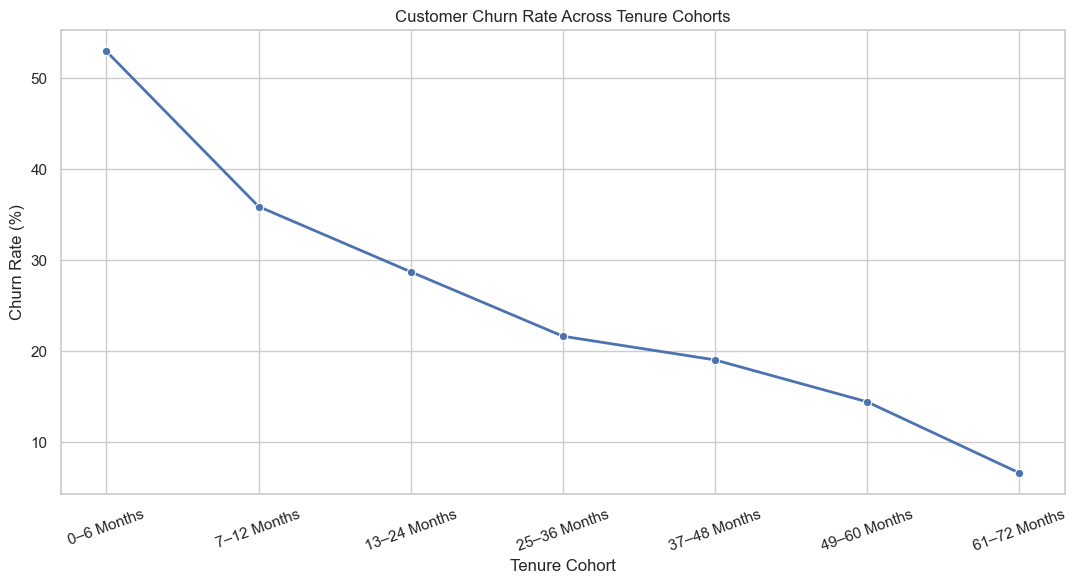

In [41]:
# ============================================================
# CUSTOMER CHURN RATE ACROSS TENURE COHORTS
# ============================================================

# Recreate cohort analysis to ensure the required columns exist
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["Churn_Binary"] = pd.to_numeric(df["Churn_Binary"], errors="coerce")

df["Tenure_Cohort"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        "0–6 Months",
        "7–12 Months",
        "13–24 Months",
        "25–36 Months",
        "37–48 Months",
        "49–60 Months",
        "61–72 Months"
    ],
    include_lowest=True
)

cohort_analysis = (
    df.groupby("Tenure_Cohort", observed=False)["Churn_Binary"]
    .mean()
    .mul(100)
    .reset_index()
)

cohort_analysis.columns = ["Tenure Cohort", "Churn Rate"]

# Display the cohort table
display(cohort_analysis)

# Create visualization
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=cohort_analysis,
    x="Tenure Cohort",
    y="Churn Rate",
    marker="o",
    linewidth=2
)

plt.title("Customer Churn Rate Across Tenure Cohorts")
plt.xlabel("Tenure Cohort")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

,Tenure Cohort,Churn Rate
0,0–6 Months,52.937205
1,7–12 Months,35.886525
2,13–24 Months,28.710938
3,25–36 Months,21.634615
4,37–48 Months,19.028871
5,49–60 Months,14.423077
6,61–72 Months,6.609808


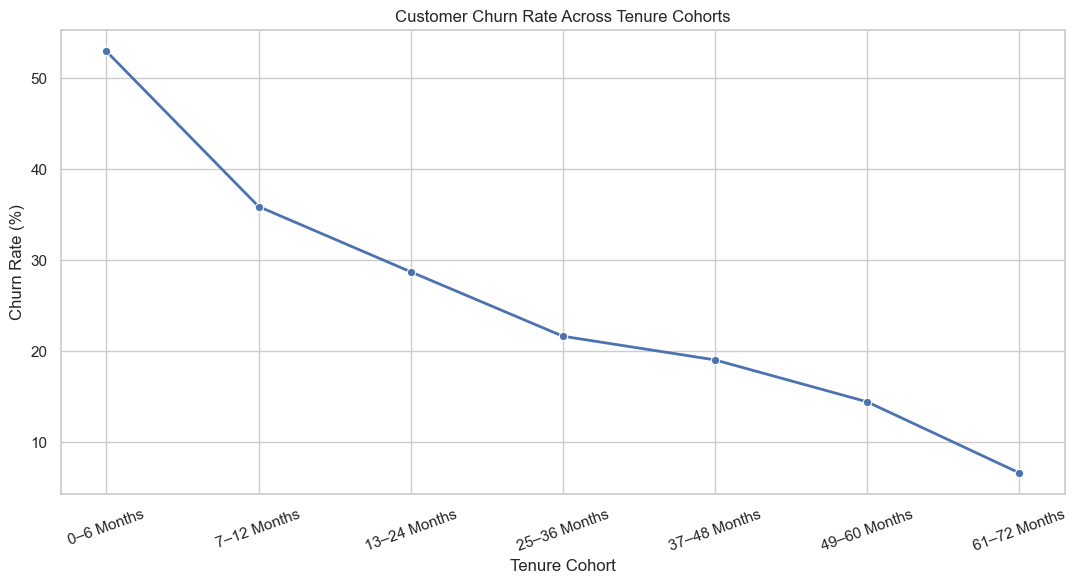

In [25]:
# ============================================================
# 25. CUSTOMER TENURE COHORT CHURN ANALYSIS
# ============================================================

# Make sure tenure and churn are numeric
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["Churn_Binary"] = pd.to_numeric(df["Churn_Binary"], errors="coerce")

# Create tenure cohorts
df["Tenure_Cohort"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        "0–6 Months",
        "7–12 Months",
        "13–24 Months",
        "25–36 Months",
        "37–48 Months",
        "49–60 Months",
        "61–72 Months"
    ],
    include_lowest=True
)

# Calculate churn rate for each cohort
cohort_analysis = (
    df.groupby("Tenure_Cohort", observed=False)["Churn_Binary"]
    .mean()
    .mul(100)
    .reset_index()
)

cohort_analysis.columns = ["Tenure Cohort", "Churn Rate"]

# Display the analysis table
display(cohort_analysis)

# Create visualization
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=cohort_analysis,
    x="Tenure Cohort",
    y="Churn Rate",
    marker="o",
    linewidth=2
)

plt.title("Customer Churn Rate Across Tenure Cohorts")
plt.xlabel("Tenure Cohort")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

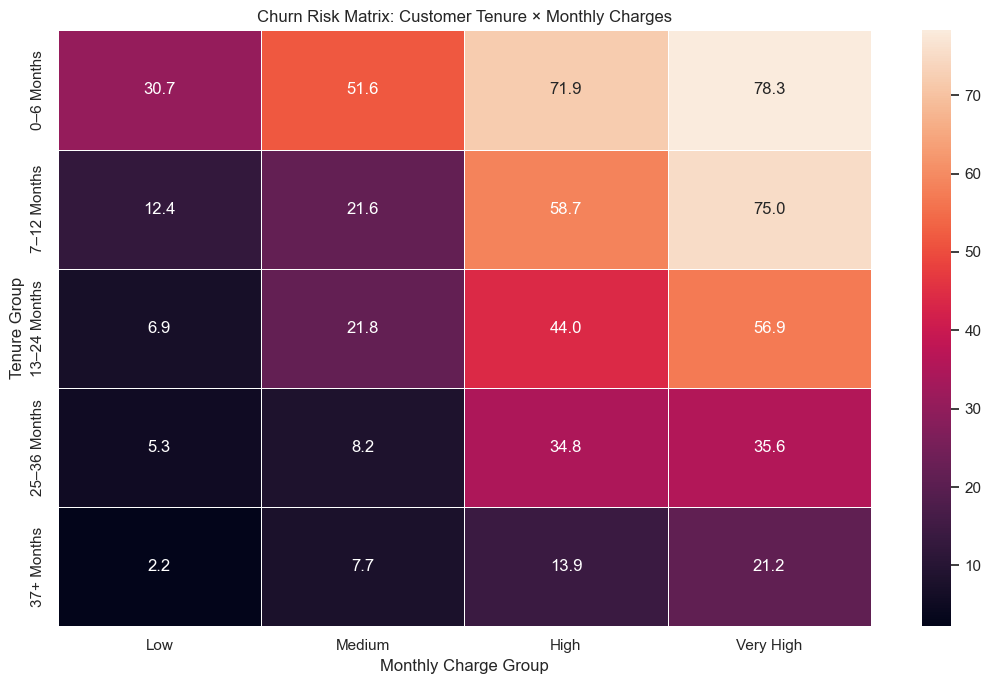

In [26]:
risk_matrix = pd.pivot_table(
    df,
    values="Churn_Binary",
    index="Tenure_Group",
    columns="Charge_Group",
    aggfunc="mean",
    observed=True
) * 100

plt.figure(figsize=(11, 7))

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Churn Risk Matrix: Customer Tenure × Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Tenure Group")

plt.tight_layout()
plt.show()

In [ ]:
##  Churn Risk Matrix

This matrix combines two important dimensions:

**Customer relationship length + monthly financial commitment**

It allows the analysis to identify combinations of customer characteristics
where churn rates differ.

This is one of the central visualizations in ChurnScope because it converts
multiple variables into an easy-to-understand business risk map.

In [27]:
conditions = [
    (df["tenure"] <= 12) & (df["MonthlyCharges"] >= df["MonthlyCharges"].median()),
    (df["tenure"] > 12) & (df["MonthlyCharges"] >= df["MonthlyCharges"].median()),
    (df["tenure"] <= 12) & (df["MonthlyCharges"] < df["MonthlyCharges"].median()),
    (df["tenure"] > 12) & (df["MonthlyCharges"] < df["MonthlyCharges"].median())
]

choices = [
    "New High-Value",
    "Loyal High-Value",
    "New Low-Value",
    "Loyal Low-Value"
]

df["Customer_Segment"] = np.select(
    conditions,
    choices,
    default="Other"
)

display(df["Customer_Segment"].value_counts())

Customer_Segment
Loyal High-Value    2690
Loyal Low-Value     2167
New Low-Value       1352
New High-Value       834
Name: count, dtype: int64

In [28]:
segment_analysis = (
    df.groupby("Customer_Segment")
    .agg(
        Customers=("customerID", "count"),
        Churn_Rate=("Churn_Binary", "mean"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean"),
        Total_Monthly_Revenue=("MonthlyCharges", "sum")
    )
)

segment_analysis["Churn_Rate"] *= 100

display(
    segment_analysis.sort_values(
        "Churn_Rate",
        ascending=False
    )
)

,Customers,Churn_Rate,Avg_Monthly_Charges,Total_Monthly_Revenue
Customer_Segment,,,,
New High-Value,834,68.585132,83.712530,69816.25
New Low-Value,1352,34.393491,39.063240,52813.50
Loyal High-Value,2690,24.758364,92.693550,249345.65
Loyal Low-Value,2167,7.660360,38.828426,84141.20


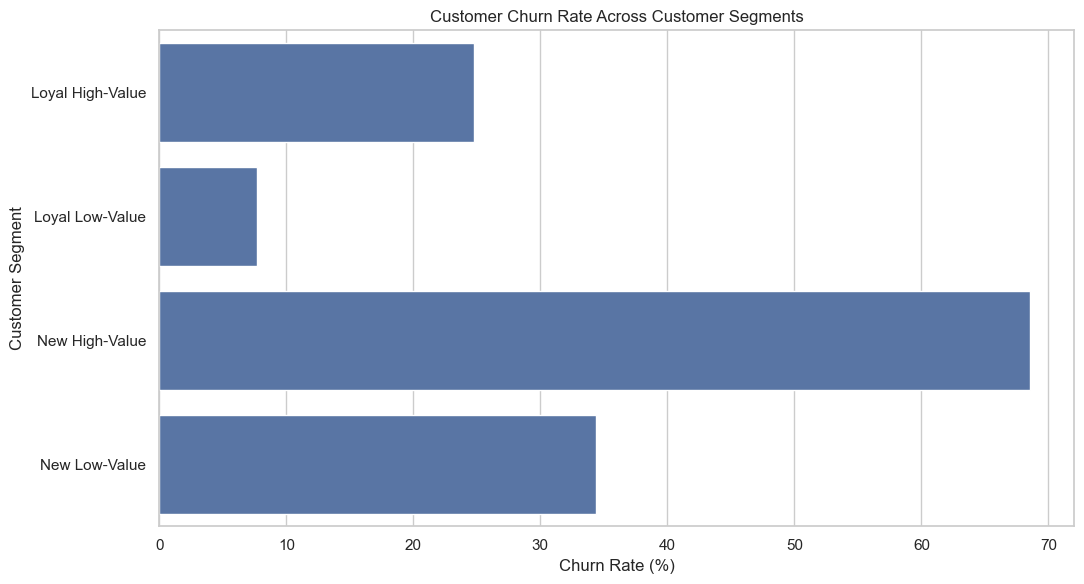

In [29]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_analysis.reset_index(),
    x="Churn_Rate",
    y="Customer_Segment"
)

plt.title("Customer Churn Rate Across Customer Segments")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [30]:
revenue_analysis = (
    df.groupby("Churn_Label")
    .agg(
        Customers=("customerID", "count"),
        Monthly_Revenue=("MonthlyCharges", "sum"),
        Average_Monthly_Charge=("MonthlyCharges", "mean")
    )
)

display(revenue_analysis)

,Customers,Monthly_Revenue,Average_Monthly_Charge
Churn_Label,,,
Churned,1869,139130.85,74.441332
Retained,5174,316985.75,61.265124


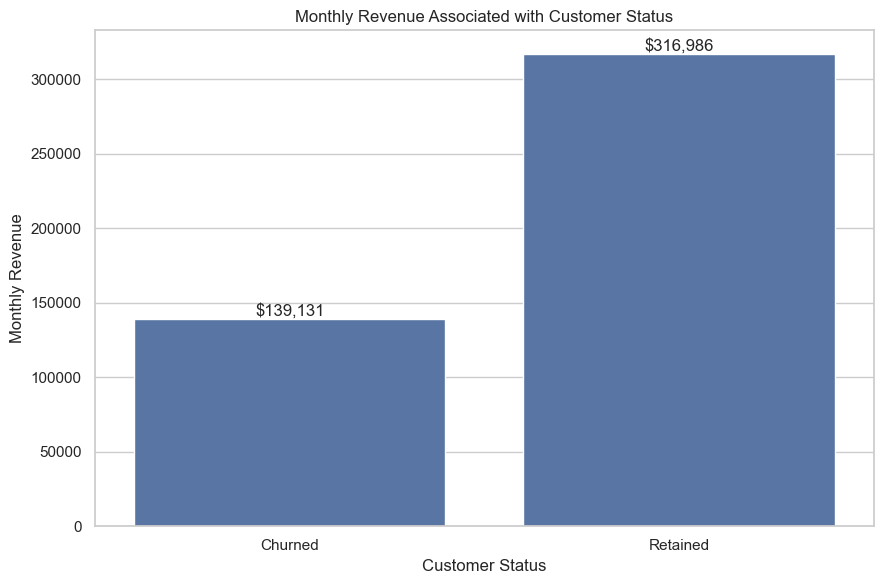

In [31]:
revenue_values = revenue_analysis["Monthly_Revenue"]

plt.figure(figsize=(9, 6))

sns.barplot(
    x=revenue_values.index,
    y=revenue_values.values
)

plt.title("Monthly Revenue Associated with Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Revenue")

for i, value in enumerate(revenue_values):
    plt.text(
        i,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
##  Revenue-at-Risk Insight

Customer churn is not only a customer-count problem.

The financial perspective allows us to estimate the recurring monthly charges
associated with customers who have churned.

This provides a business-oriented interpretation of the churn problem.

> Revenue-at-risk in this analysis represents the sum of monthly charges
> associated with churned customers. It should not be interpreted as a
> forecast of future revenue loss.

In [32]:
contingency_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test: Contract vs Churn")
print("-" * 40)
print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom  : {dof}")
print(f"P-value             : {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: The variables show a statistically significant association.")
else:
    print("\nResult: The test does not show a statistically significant association.")

Chi-Square Test: Contract vs Churn
----------------------------------------
Chi-square statistic : 1184.5966
Degrees of freedom  : 2
P-value             : 0.000000

Result: The variables show a statistically significant association.


In [33]:
contingency_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Test: Contract vs Churn")
print("-" * 40)
print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom  : {dof}")
print(f"P-value             : {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: The variables show a statistically significant association.")
else:
    print("\nResult: The test does not show a statistically significant association.")

Chi-Square Test: Contract vs Churn
----------------------------------------
Chi-square statistic : 1184.5966
Degrees of freedom  : 2
P-value             : 0.000000

Result: The variables show a statistically significant association.


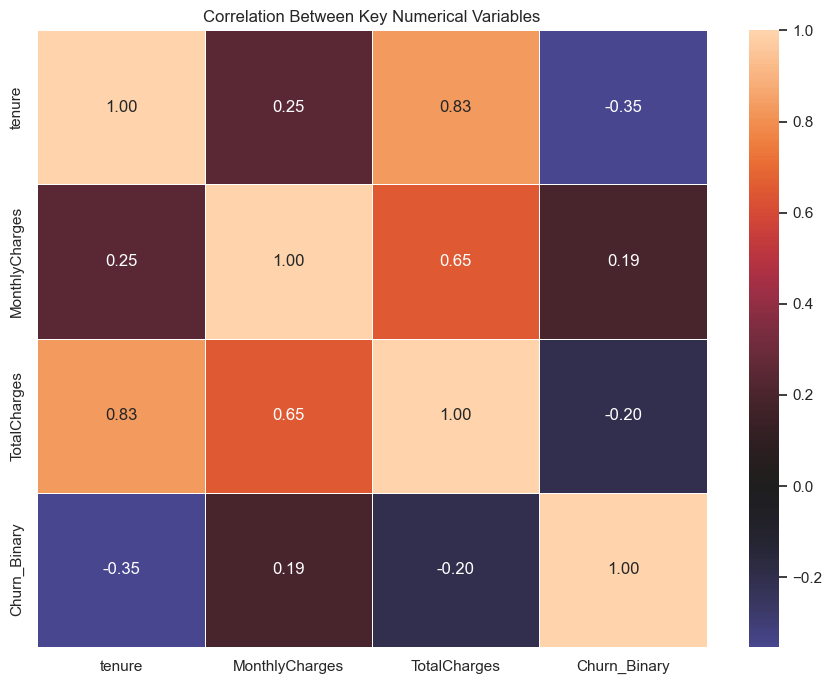

In [34]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Binary"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Between Key Numerical Variables")

plt.tight_layout()
plt.show()

In [ ]:
##  Important Interpretation Note

Correlation measures the strength of a linear relationship between numerical
variables. It does not establish causation.

Therefore, the correlations observed here should be interpreted as
relationships within the dataset rather than proof that one variable causes
another.

In [36]:
final_insights = pd.DataFrame({
    "Analysis Area": [
        "Overall Churn",
        "Contract",
        "Tenure",
        "Monthly Charges",
        "Payment Method",
        "Customer Segmentation",
        "Revenue Risk"
    ],
    "Key Metric": [
        f"{churn_rate:.2f}%",
        df.groupby("Contract")["Churn_Binary"].mean().max() * 100,
        df[df["Churn_Binary"] == 1]["tenure"].mean(),
        df[df["Churn_Binary"] == 1]["MonthlyCharges"].mean(),
        payment_churn.max(),
        segment_analysis["Churn_Rate"].max(),
        revenue_at_risk
    ]
})

display(final_insights)

,Analysis Area,Key Metric
0,Overall Churn,26.54%
1,Contract,42.709677
2,Tenure,17.979133
3,Monthly Charges,74.441332
4,Payment Method,45.285412
5,Customer Segmentation,68.585132
6,Revenue Risk,139130.85


In [37]:
highest_contract_churn = (
    df.groupby("Contract")["Churn_Binary"]
    .mean()
    .idxmax()
)

highest_contract_rate = (
    df.groupby("Contract")["Churn_Binary"]
    .mean()
    .max() * 100
)

highest_payment = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

highest_segment = segment_analysis["Churn_Rate"].idxmax()
highest_segment_rate = segment_analysis["Churn_Rate"].max()

summary = f"""
# Executive Summary — ChurnScope

ChurnScope analyzed {total_customers:,} customers to understand customer
retention patterns, behavioral differences and revenue exposure.

### Key Findings

1. The overall customer churn rate is {churn_rate:.2f}%.

2. The contract category with the highest observed churn rate is
   {highest_contract_churn}, at approximately {highest_contract_rate:.2f}%.

3. The average tenure of churned customers is
   {df[df["Churn_Binary"] == 1]["tenure"].mean():.2f} months.

4. The average monthly charge among churned customers is
   ${df[df["Churn_Binary"] == 1]["MonthlyCharges"].mean():.2f}.

5. The payment method with the highest observed churn rate is
   {highest_payment}, at approximately {highest_payment_rate:.2f}%.

6. The customer segment with the highest observed churn rate is
   {highest_segment}, at approximately {highest_segment_rate:.2f}%.

7. The monthly charges associated with churned customers total approximately
   ${revenue_at_risk:,.2f}.

### Overall Perspective

The analysis demonstrates that customer churn is influenced by multiple
observable dimensions rather than a single variable. Contract structure,
customer tenure, monthly charges, payment behavior and customer segment
provide complementary perspectives on retention.

These findings can help organizations prioritize further investigation into
customer experience and retention strategies.
"""

display(Markdown(summary))


# Executive Summary — ChurnScope

ChurnScope analyzed 7,043 customers to understand customer
retention patterns, behavioral differences and revenue exposure.

### Key Findings

1. The overall customer churn rate is 26.54%.

2. The contract category with the highest observed churn rate is
   Month-to-month, at approximately 42.71%.

3. The average tenure of churned customers is
   17.98 months.

4. The average monthly charge among churned customers is
   $74.44.

5. The payment method with the highest observed churn rate is
   Electronic check, at approximately 45.29%.

6. The customer segment with the highest observed churn rate is
   New High-Value, at approximately 68.59%.

7. The monthly charges associated with churned customers total approximately
   $139,130.85.

### Overall Perspective

The analysis demonstrates that customer churn is influenced by multiple
observable dimensions rather than a single variable. Contract structure,
customer tenure, monthly charges, payment behavior and customer segment
provide complementary perspectives on retention.

These findings can help organizations prioritize further investigation into
customer experience and retention strategies.


In [ ]:
# Conclusion

ChurnScope transformed a customer-level dataset into a structured visual
story about customer retention and churn.

The analysis combined descriptive statistics, advanced visualizations,
customer segmentation, risk mapping, revenue analysis and statistical
testing to explore the characteristics associated with customer churn.

The project demonstrates how data visualization can move beyond presenting
charts and instead communicate a coherent business story.

### Major analytical themes

- Understanding the overall scale of churn
- Exploring customer tenure and behavior
- Comparing contract and service patterns
- Identifying customer segments
- Mapping potential churn-risk combinations
- Quantifying revenue associated with churned customers
- Validating selected relationships statistically

### Business Implication

The findings can support further customer-retention analysis by identifying
customer groups and behavioral patterns that warrant deeper investigation.

### Limitation

The analysis identifies associations within the available dataset.
It does not establish causal relationships or predict future customer churn.

### Future Scope

Future versions of ChurnScope could incorporate:

- Machine Learning-based churn prediction
- Customer lifetime value prediction
- Explainable AI
- Real-time churn monitoring
- Interactive business dashboards
- Automated customer-risk scoring

In [ ]:
# Technologies & Libraries

### Programming
- Python

### Data Analysis
- Pandas
- NumPy

### Visualization
- Matplotlib
- Seaborn
- Plotly

### Statistical Analysis
- SciPy

### Environment
- Jupyter Notebook

---

**Project:** ChurnScope  
**Focus:** Advanced Data Visualization & Data Storytelling  
**Domain:** Customer Analytics / Data Science

In [ ]:
# References

1. Public Telco Customer Churn dataset.
2. Pandas documentation.
3. NumPy documentation.
4. Matplotlib documentation.
5. Seaborn documentation.
6. Plotly documentation.
7. SciPy documentation.

All analysis, transformations and visualizations in this notebook were
performed using Python.

In [ ]:
#  Executive Summary

ChurnScope analyzed customer behavior using the Telco Customer Churn dataset to understand churn patterns, customer retention, segmentation, and potential revenue exposure.

The analysis combines descriptive statistics, advanced visualizations, interactive Plotly charts, customer segmentation, tenure analysis, and statistical techniques to transform raw customer data into an understandable visual story.

The analysis focuses on four major questions:

- **Who** are the customers associated with higher churn patterns?
- **What** customer characteristics are associated with observed churn?
- **Which** customer segments show meaningful differences in retention?
- **What** potential revenue exposure is associated with customer churn?

The visualizations provide a business-oriented perspective that allows non-technical audiences to understand customer behavior without relying only on raw numerical tables.

In [38]:
# ============================================================
# 41. FINAL EXECUTIVE KPIs
# ============================================================

total_customers = len(df)
churned_customers = (df["Churn_Binary"] == 1).sum()
retained_customers = (df["Churn_Binary"] == 0).sum()

overall_churn_rate = df["Churn_Binary"].mean() * 100
overall_retention_rate = 100 - overall_churn_rate

average_tenure = df["tenure"].mean()
average_monthly_charge = df["MonthlyCharges"].mean()

monthly_revenue_at_risk = df.loc[
    df["Churn_Binary"] == 1,
    "MonthlyCharges"
].sum()

print("=" * 55)
print("             CHURNSCOPE — EXECUTIVE KPIs")
print("=" * 55)

print(f"Total Customers       : {total_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Retained Customers    : {retained_customers:,}")
print(f"Overall Churn Rate    : {overall_churn_rate:.2f}%")
print(f"Retention Rate        : {overall_retention_rate:.2f}%")
print(f"Average Tenure        : {average_tenure:.2f} months")
print(f"Average Monthly Charge: ${average_monthly_charge:.2f}")
print(f"Monthly Revenue at Risk: ${monthly_revenue_at_risk:,.2f}")

print("=" * 55)

             CHURNSCOPE — EXECUTIVE KPIs
Total Customers       : 7,043
Churned Customers     : 1,869
Retained Customers    : 5,174
Overall Churn Rate    : 26.54%
Retention Rate        : 73.46%
Average Tenure        : 32.37 months
Average Monthly Charge: $64.76
Monthly Revenue at Risk: $139,130.85


In [39]:
# ============================================================
# 42. KEY FINDINGS FROM THE ANALYSIS
# ============================================================

# Contract-level churn
contract_churn = (
    df.groupby("Contract")["Churn_Binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Payment method churn
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Internet service churn
internet_churn = (
    df.groupby("InternetService")["Churn_Binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Tenure group churn
tenure_churn_final = (
    df.groupby("Tenure_Group", observed=False)["Churn_Binary"]
    .mean()
    .mul(100)
)

print("KEY FINDINGS")
print("-" * 55)

print(
    f"Highest observed contract-level churn: "
    f"{contract_churn.index[0]} ({contract_churn.iloc[0]:.2f}%)"
)

print(
    f"Highest observed payment-method churn: "
    f"{payment_churn.index[0]} ({payment_churn.iloc[0]:.2f}%)"
)

print(
    f"Highest observed internet-service churn: "
    f"{internet_churn.index[0]} ({internet_churn.iloc[0]:.2f}%)"
)

print(
    f"Highest observed tenure-group churn: "
    f"{tenure_churn_final.idxmax()} ({tenure_churn_final.max():.2f}%)"
)

print(
    f"Monthly charges among churned customers: "
    f"${df.loc[df['Churn_Binary'] == 1, 'MonthlyCharges'].mean():.2f} average"
)

print("-" * 55)
print("Note: These findings describe patterns in the dataset and do not establish causation.")

KEY FINDINGS
-------------------------------------------------------
Highest observed contract-level churn: Month-to-month (42.71%)
Highest observed payment-method churn: Electronic check (45.29%)
Highest observed internet-service churn: Fiber optic (41.89%)
Highest observed tenure-group churn: 0–6 Months (52.94%)
Monthly charges among churned customers: $74.44 average
-------------------------------------------------------
Note: These findings describe patterns in the dataset and do not establish causation.


In [ ]:
# 🏁 Final Conclusions

ChurnScope demonstrates how data visualization can transform a customer dataset into a clear and meaningful analytical story.

The analysis examined customer churn from multiple perspectives, including tenure, monthly charges, contracts, services, payment methods, customer segments, and revenue exposure.

Several important patterns can be observed through the visual analysis. However, these patterns should be interpreted as associations within the dataset rather than proof of direct causation.

The combination of statistical analysis and visualization makes it easier to identify customer groups that may deserve further retention analysis.

### Key Takeaways

1. **Customer churn is not evenly distributed across all customer groups.**

2. **Customer tenure provides an important dimension for understanding retention patterns.**

3. **Contract structure and payment methods show differences in observed churn rates.**

4. **Monthly charges provide another useful dimension for examining customer behavior.**

5. **Customer segmentation helps transform a large customer population into smaller, more understandable groups.**

6. **Revenue-at-risk analysis connects customer behavior with a business perspective.**

7. **Interactive visualizations allow users to explore individual customer patterns beyond static charts.**

### Overall Insight

The main value of ChurnScope is not a single chart or metric. It is the combination of multiple perspectives that turns raw customer records into an understandable visual narrative.

> **Data → Patterns → Insights → Business Understanding**

ChurnScope demonstrates how Python-based data visualization can support better exploration and communication of customer analytics.

In [ ]:
#  Project Completed

## ChurnScope — Advanced Data Visualization & Storytelling

**Domain:** Customer Analytics / Data Science

**Dataset:** Telco Customer Churn

**Customers Analyzed:** 7,043

**Primary Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, SciPy

### Project Workflow

**Data Collection → Data Cleaning → Exploration → Visualization → Segmentation → Statistical Analysis → Revenue Analysis → Data Storytelling → Business Insights**

---

###  Developed By

**Rohan Bhowmik**

**Aspiring AI/ML • Data Science • GenAI • Web Development**

---

###  Project Philosophy

> **Explore Data • Discover Patterns • Tell the Story**

This project was developed as an advanced data visualization and storytelling case study, with the goal of making analytical findings understandable to both technical and non-technical audiences.